# 07 — Statistical Analysis

Analysis over the processed per-sample data:
1. **Data overview** — sample counts and label distribution
2. **Word-category analysis** — partition shared / verbalized-only / LRP-only words across ENTITY / EMOTIONAL / RHETORIC / CONTENT / OTHER
3. **Disagreement analysis** — top samples by lowest LRP↔verbalized Jaccard


In [1]:
CONFIG = {
    "dataset_path": "../../datasets/ukrainian/",
    "language": "uk",
    "processed_dir": "./data/processed",
    "vlm_explanations_dir": "./data/vlm_explanations",
    "lrp_results_dir": "./data/lrp_results",
    "output_dir": "./data/analysis_outputs",
    "modes": ["text", "image", "image+text"],
    "default_threshold": 25,  # jaccard_20
    "palette": ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"],
    "seed": 42,
}

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from scipy.stats import (
    chi2_contingency, mannwhitneyu, pearsonr,
    pointbiserialr, shapiro, spearmanr,
)

sns.set_theme(style="whitegrid", palette=CONFIG["palette"])
OUT_DIR = Path(CONFIG["output_dir"])
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Load all processed DataFrames
dfs = {}
for mode in CONFIG["modes"]:
    mode_key = mode.replace("+", "_")
    p = Path(CONFIG["processed_dir"]) / f"{mode_key}_processed.parquet"
    if p.exists():
        dfs[mode] = pd.read_parquet(p)
        print(f"Loaded [{mode}]: {len(dfs[mode])} rows")
    else:
        print(f"[{mode}] NOT FOUND: {p}")

df_all = pd.concat(dfs.values(), ignore_index=True) if dfs else pd.DataFrame()
# Default: image+text mode for main analysis
df = dfs.get("image+text", dfs.get("text", df_all))
JACCARD_COL = f"jaccard_{CONFIG['default_threshold']}"
print(f"\nPrimary analysis dataframe: {len(df)} rows | jaccard column: {JACCARD_COL}")

Loaded [text]: 158 rows
[image] NOT FOUND: data/processed/image_processed.parquet
Loaded [image+text]: 158 rows

Primary analysis dataframe: 158 rows | jaccard column: jaccard_25


## Section 1: Data Overview

In [3]:
print("=== Sample counts per mode ===")
for mode, d in dfs.items():
    trivial = d["is_trivial"].sum()
    print(f"  {mode}: {len(d)} samples, {trivial} trivial ({trivial/len(d)*100:.1f}%)")

print("\n=== Gold label distribution ===")
print(df["n_gold_labels"].value_counts().sort_index())

print("\n=== Propaganda techniques ===")
all_techs = [t for techniques in df["techniques"].dropna() for t in techniques.split("|") if t]
from collections import Counter
tech_counts = Counter(all_techs)
for tech, cnt in tech_counts.most_common():
    print(f"  {cnt:4d}  {tech}")

print(f"\n=== Trivial cases ===")
print(f"  Trivial (both gold and pred empty): {df['is_trivial'].sum()} / {len(df)}")

=== Sample counts per mode ===
  text: 158 samples, 0 trivial (0.0%)
  image+text: 158 samples, 0 trivial (0.0%)

=== Gold label distribution ===
n_gold_labels
1    30
2    51
3    40
4    28
5     4
6     5
Name: count, dtype: int64

=== Propaganda techniques ===
    84  Smears
    77  Loaded Language
    50  Name calling/Labeling
    37  Doubt
    23  Exaggeration/Minimisation
    18  Transfer
    18  Slogans
    16  Glittering generalities (Virtue)
    15  Appeal to (Strong) Emotions
    12  Appeal to fear/prejudice
    12  Whataboutism
    11  Appeal to authority
     9  Flag-waving
     6  Reductio ad hitlerum
     5  Presenting Irrelevant Data (Red Herring)
     5  Black-and-white Fallacy/Dictatorship
     4  Causal Oversimplification
     4  Thought-terminating cliché
     3  Misrepresentation of Someone's Position (Straw Man)
     2  NO_PROPAGANDA
     1  Repetition
     1  Bandwagon
     1  Obfuscation, Intentional vagueness, Confusion

=== Trivial cases ===
  Trivial (both go

## Section 9: Word Category Analysis

Source breakdown:
source
llm_only    637
Name: count, dtype: int64

Category breakdown:
category
EMOTIONAL    212
CONTENT      149
RHETORIC     130
ENTITY       118
OTHER         28
Name: count, dtype: int64

Chi-square (all sources): χ²=0.00, dof=0, p=1.0000


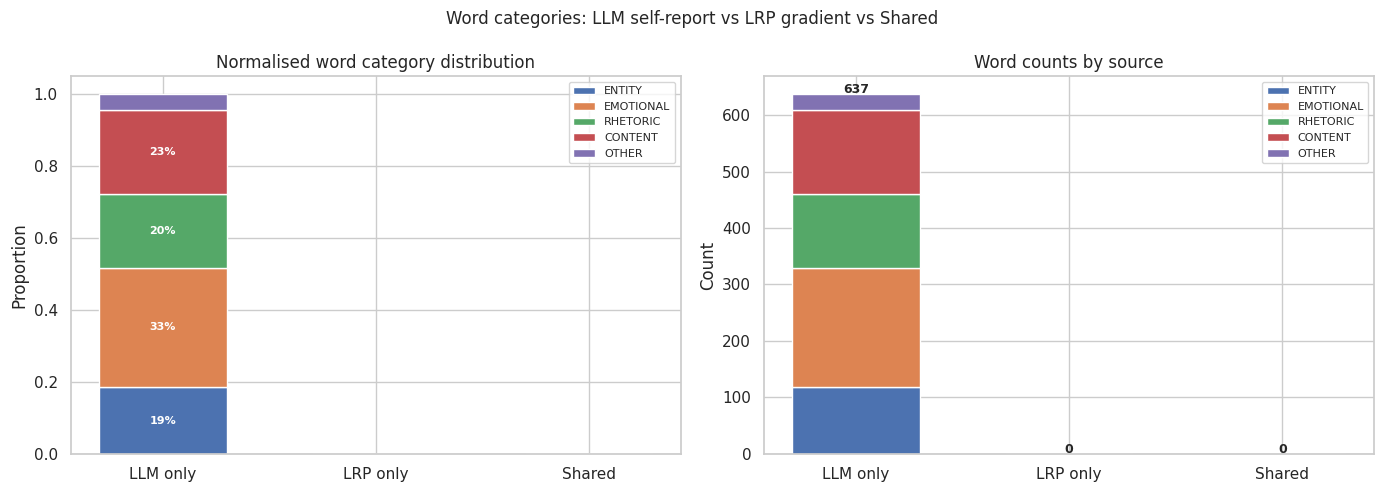

In [4]:
df = dfs.get("image+text")
CATEGORIES = ["ENTITY", "EMOTIONAL", "RHETORIC", "CONTENT", "OTHER"]
SOURCES = ["llm", "lrp"]

# Build word records dataframe
word_records = []
for _, row in df.iterrows():
    wc = row.get("word_categories") or {}
    if isinstance(wc, str):
        try: wc = json.loads(wc)
        except: wc = {}

    llm_w = set([])
    if any(row.get("llm_words")):
        llm_w = set(row.get("llm_words"))
    
    lrp_w = set([])
    if any(row.get("lrp_words")):
        lrp_w = set(row.get("lrp_words"))
    for word, cat in wc.items():
        in_llm = word in llm_w
        in_lrp = word in lrp_w
        if in_llm and in_lrp:
            src = "shared"
        elif in_llm:
            src = "llm_only"
        elif in_lrp:
            src = "lrp_only"
        else:
            continue
        word_records.append({"word": word, "source": src, "category": cat})

word_df = pd.DataFrame(word_records)
if not word_df.empty:
    print("Source breakdown:")
    print(word_df["source"].value_counts())
    print("\nCategory breakdown:")
    print(word_df["category"].value_counts())

    # Chi-squared test
    ct = pd.crosstab(word_df["source"], word_df["category"])
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f"\nChi-square (all sources): χ²={chi2:.2f}, dof={dof}, p={p:.4f}")

    # Stacked bar
    SRCS = ["llm_only", "lrp_only", "shared"]
    counts = {s: [word_df[(word_df["source"]==s) & (word_df["category"]==c)].shape[0]
                  for c in CATEGORIES] for s in SRCS}
    totals = {s: sum(counts[s]) for s in SRCS}
    props = {s: [v/totals[s] if totals[s] else 0 for v in counts[s]] for s in SRCS}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(SRCS))
    bottom = np.zeros(len(SRCS))
    for i, (cat, color) in enumerate(zip(CATEGORIES, CONFIG["palette"])):
        vals = [props[s][i] for s in SRCS]
        ax1.bar(x, vals, 0.6, bottom=bottom, label=cat, color=color)
        for j, (v, b) in enumerate(zip(vals, bottom)):
            if v > 0.05:
                ax1.text(x[j], b+v/2, f"{v:.0%}", ha="center", va="center",
                         fontsize=8, color="white", fontweight="bold")
        bottom += np.array(vals)
    ax1.set_xticks(x); ax1.set_xticklabels(["LLM only", "LRP only", "Shared"])
    ax1.set_ylabel("Proportion"); ax1.set_title("Normalised word category distribution")
    ax1.legend(loc="upper right", fontsize=8)

    bottom = np.zeros(len(SRCS))
    for i, (cat, color) in enumerate(zip(CATEGORIES, CONFIG["palette"])):
        vals = [counts[s][i] for s in SRCS]
        ax2.bar(x, vals, 0.6, bottom=bottom, label=cat, color=color)
        bottom += np.array(vals)
    for j, s in enumerate(SRCS):
        ax2.text(x[j], totals[s]+2, str(totals[s]), ha="center", fontsize=9, fontweight="bold")
    ax2.set_xticks(x); ax2.set_xticklabels(["LLM only", "LRP only", "Shared"])
    ax2.set_ylabel("Count"); ax2.set_title("Word counts by source")
    ax2.legend(loc="upper right", fontsize=8)

    plt.suptitle("Word categories: LLM self-report vs LRP gradient vs Shared", fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "s9_word_categories.png", dpi=150, bbox_inches="tight")
    plt.show()

Source breakdown:
source
llm_only    468
Name: count, dtype: int64

Category breakdown:
category
EMOTIONAL    165
ENTITY       104
RHETORIC      90
CONTENT       85
OTHER         22
Name: count, dtype: int64

Chi-square (all sources): χ²=0.00, dof=0, p=1.0000


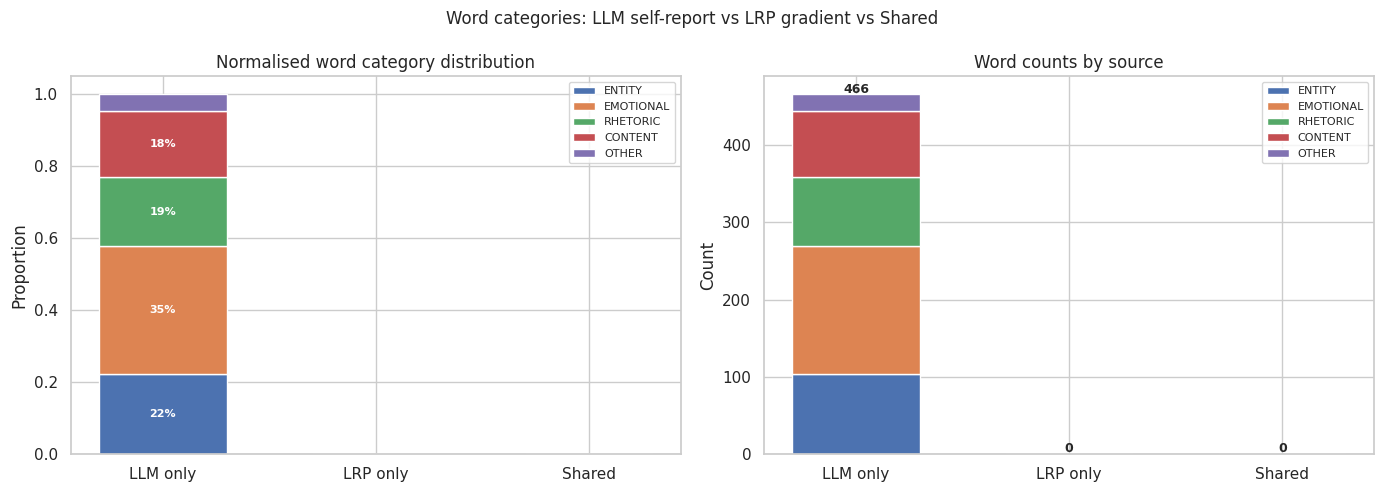

In [5]:
df = dfs.get("text")
CATEGORIES = ["ENTITY", "EMOTIONAL", "RHETORIC", "CONTENT", "OTHER"]
SOURCES = ["llm", "lrp"]

# Build word records dataframe
word_records = []
for _, row in df.iterrows():
    wc = row.get("word_categories") or {}
    if isinstance(wc, str):
        try: wc = json.loads(wc)
        except: wc = {}

    llm_w = set([])
    if any(row.get("llm_words")):
        llm_w = set(row.get("llm_words"))
    
    lrp_w = set([])
    if any(row.get("lrp_words")):
        lrp_w = set(row.get("lrp_words"))
    for word, cat in wc.items():
        in_llm = word in llm_w
        in_lrp = word in lrp_w
        if in_llm and in_lrp:
            src = "shared"
        elif in_llm:
            src = "llm_only"
        elif in_lrp:
            src = "lrp_only"
        else:
            continue
        word_records.append({"word": word, "source": src, "category": cat})

word_df = pd.DataFrame(word_records)
if not word_df.empty:
    print("Source breakdown:")
    print(word_df["source"].value_counts())
    print("\nCategory breakdown:")
    print(word_df["category"].value_counts())

    # Chi-squared test
    ct = pd.crosstab(word_df["source"], word_df["category"])
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f"\nChi-square (all sources): χ²={chi2:.2f}, dof={dof}, p={p:.4f}")

    # Stacked bar
    SRCS = ["llm_only", "lrp_only", "shared"]
    counts = {s: [word_df[(word_df["source"]==s) & (word_df["category"]==c)].shape[0]
                  for c in CATEGORIES] for s in SRCS}
    totals = {s: sum(counts[s]) for s in SRCS}
    props = {s: [v/totals[s] if totals[s] else 0 for v in counts[s]] for s in SRCS}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(SRCS))
    bottom = np.zeros(len(SRCS))
    for i, (cat, color) in enumerate(zip(CATEGORIES, CONFIG["palette"])):
        vals = [props[s][i] for s in SRCS]
        ax1.bar(x, vals, 0.6, bottom=bottom, label=cat, color=color)
        for j, (v, b) in enumerate(zip(vals, bottom)):
            if v > 0.05:
                ax1.text(x[j], b+v/2, f"{v:.0%}", ha="center", va="center",
                         fontsize=8, color="white", fontweight="bold")
        bottom += np.array(vals)
    ax1.set_xticks(x); ax1.set_xticklabels(["LLM only", "LRP only", "Shared"])
    ax1.set_ylabel("Proportion"); ax1.set_title("Normalised word category distribution")
    ax1.legend(loc="upper right", fontsize=8)

    bottom = np.zeros(len(SRCS))
    for i, (cat, color) in enumerate(zip(CATEGORIES, CONFIG["palette"])):
        vals = [counts[s][i] for s in SRCS]
        ax2.bar(x, vals, 0.6, bottom=bottom, label=cat, color=color)
        bottom += np.array(vals)
    for j, s in enumerate(SRCS):
        ax2.text(x[j], totals[s]+2, str(totals[s]), ha="center", fontsize=9, fontweight="bold")
    ax2.set_xticks(x); ax2.set_xticklabels(["LLM only", "LRP only", "Shared"])
    ax2.set_ylabel("Count"); ax2.set_title("Word counts by source")
    ax2.legend(loc="upper right", fontsize=8)

    plt.suptitle("Word categories: LLM self-report vs LRP gradient vs Shared", fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "s9_word_categories.png", dpi=150, bbox_inches="tight")
    plt.show()

[text] Chi-square: χ²=0.00, dof=0, p=1.0000
[image+text] Chi-square: χ²=0.00, dof=0, p=1.0000


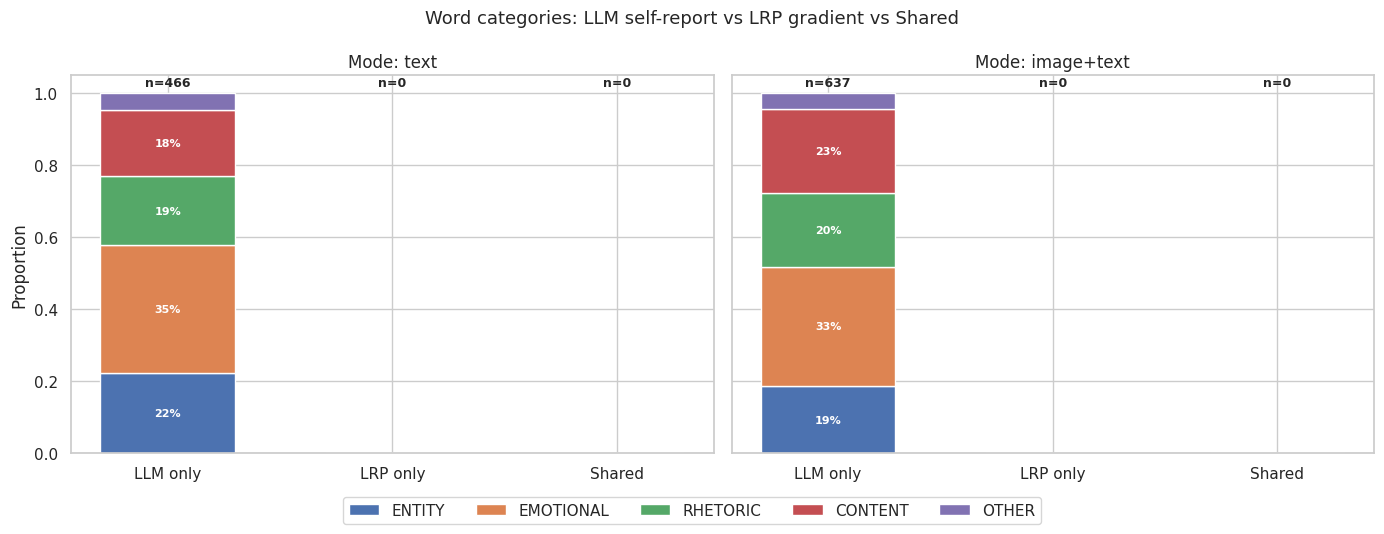

In [6]:
CATEGORIES = ["ENTITY", "EMOTIONAL", "RHETORIC", "CONTENT", "OTHER"]
SRCS = ["llm_only", "lrp_only", "shared"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, mode in zip(axes, ["text", "image+text"]):
    df = dfs.get(mode)
    
    word_records = []
    for _, row in df.iterrows():
        wc = row.get("word_categories") or {}
        if isinstance(wc, str):
            try: wc = json.loads(wc)
            except: wc = {}

        llm_w = set(row.get("llm_words")) if any(row.get("llm_words")) else set()
        lrp_w = set(row.get("lrp_words")) if any(row.get("lrp_words")) else set()

        for word, cat in wc.items():
            in_llm = word in llm_w
            in_lrp = word in lrp_w
            if in_llm and in_lrp:
                src = "shared"
            elif in_llm:
                src = "llm_only"
            elif in_lrp:
                src = "lrp_only"
            else:
                continue
            word_records.append({"word": word, "source": src, "category": cat})

    word_df = pd.DataFrame(word_records)
    if word_df.empty:
        continue

    ct = pd.crosstab(word_df["source"], word_df["category"])
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f"[{mode}] Chi-square: χ²={chi2:.2f}, dof={dof}, p={p:.4f}")

    counts = {s: [word_df[(word_df["source"]==s) & (word_df["category"]==c)].shape[0]
                  for c in CATEGORIES] for s in SRCS}
    totals = {s: sum(counts[s]) for s in SRCS}
    props = {s: [v/totals[s] if totals[s] else 0 for v in counts[s]] for s in SRCS}

    x = np.arange(len(SRCS))
    bottom = np.zeros(len(SRCS))
    for i, (cat, color) in enumerate(zip(CATEGORIES, CONFIG["palette"])):
        vals = [props[s][i] for s in SRCS]
        cnt_vals = [counts[s][i] for s in SRCS]
        ax.bar(x, vals, 0.6, bottom=bottom, label=cat, color=color)
        for j, (v, b, c) in enumerate(zip(vals, bottom, cnt_vals)):
            if v > 0.05:
                ax.text(x[j], b+v/2, f"{v:.0%}", ha="center", va="center",
                        fontsize=8, color="white", fontweight="bold")
        bottom += np.array(vals)
    for j, s in enumerate(SRCS):
        ax.text(x[j], 1.02, f"n={totals[s]}", ha="center", fontsize=9, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(["LLM only", "LRP only", "Shared"])
    ax.set_title(f"Mode: {mode}")

axes[0].set_ylabel("Proportion")
# Single legend from first axes
handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper right", fontsize=8, bbox_to_anchor=(0.99, 0.95))
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.02), ncol=5)

fig.suptitle("Word categories: LLM self-report vs LRP gradient vs Shared", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "s9_word_categories.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 11: Disagreement Analysis

In [ ]:
# Top samples with highest LRP-VLM disagreement (low Jaccard, non-trivial)
disagree = df[df["is_trivial"] == 0].nsmallest(30, JACCARD_COL)

print(f"=== Top 30 disagreement samples (lowest Jaccard @ {CONFIG['default_threshold']}%) ===")
print(disagree[["sample_id", "f1", JACCARD_COL, "n_gold_labels", "text_length", "techniques"]].to_string(index=False))

print("\n=== Disagreement patterns ===")
print("Mean text length (disagree vs agree top quartile):")
agree_top = df.nlargest(30, JACCARD_COL)
print(f"  Low agreement:  {disagree['text_length'].mean():.1f} words")
print(f"  High agreement: {agree_top['text_length'].mean():.1f} words")

print("\nMean n_gold_labels:")
print(f"  Low agreement:  {disagree['n_gold_labels'].mean():.2f}")
print(f"  High agreement: {agree_top['n_gold_labels'].mean():.2f}")

print("\nPropaganda technique frequency in disagreement set:")
disagree_techs = Counter(
    t for tech_str in disagree["techniques"].dropna()
    for t in tech_str.split("|") if t
)
for tech, cnt in disagree_techs.most_common(10):
    print(f"  {cnt:3d}  {tech}")

=== Top 30 disagreement samples (lowest Jaccard @ 25%) ===
                            sample_id       f1  jaccard_25  n_gold_labels  text_length                                                                             techniques
csv_1QOtqqVGS9dXu17pwVMP2gC-KW8yY5BC- 0.000000    0.000000              3           13         Appeal to authority|Misrepresentation of Someone's Position (Straw Man)|Smears
csv_1SKjQSE5W5hwfdKP2jmnp5_bOABLbDhti 0.000000    0.000000              4           26              Appeal to fear/prejudice|Glittering generalities (Virtue)|Smears|Transfer
csv_1h8DQF6VfAKCrSzMXoisCLwCjSZ85V290 0.000000    0.000000              2           17                                           Flag-waving|Glittering generalities (Virtue)
                              tg_5295 0.000000    0.000000              1           29                                                                          NO_PROPAGANDA
                              tg_5312 0.000000    0.000000             